In [1]:
import numpy as np
from typing import List, Dict, Union, Tuple
from tenpy.networks.site import SpinSite
from tenpy.linalg import np_conserved as npc
from tenpy.linalg.np_conserved import Array
from tenpy.networks.mpo import MPO
from tenpy.models.model import MPOModel
from tenpy.models.lattice import Chain
from tenpy.networks.mps import MPS  
from tenpy.algorithms.network_contractor import ncon

In [2]:
def _dirichlet_weight(rng: np.random.Generator, n: int, alpha: float = 1.0) -> np.ndarray:
    """
    Return w ∈ R^n, w ≥ 0, sum(w) = 1.
    Samples w via independent Gamma(alpha,1) and normalizing.
    - alpha = 1.0  → uniform over the simplex (flat with no bias).
    - alpha < 1.0  → spikier (few large entries, many near zero).
    - alpha > 1.0  → smoother (entries more even).
    Edge cases:
      n = 0 → empty vector, n = 1 → [1.0].
    """

    #Sanity checks to avoid useless computation (R^0 and R vectors)
    if n == 0:
        return np.empty((0,), dtype=np.float64)
    if n == 1:
        return np.array([1.0], dtype=np.float64)
    #Invalid parameter
    if alpha <= 0:
        raise ValueError("dirichlet_alpha must be > 0.")
    
    
    #Gamma sampled vector of R^n
    g = rng.gamma(shape=alpha, scale=1.0, size=n)
    
    #Sum of the vector 
    s = g.sum()
    
    # numerically, s > 0 almost surely for alpha>0; still guard:
    if s == 0.0:
        # extremely unlikely; fallback to a one-hot at a random index
        w = np.zeros(n, dtype=np.float64)
        w[rng.integers(n)] = 1.0
        return w
    return g / s


# --------- Validators (keep constraints honest) ----------

def _check_L_row_substochastic(L: np.ndarray, atol: float = 1e-12):
    # For each (x,i): sum_j L[x,i,j] ≤ 1
    row_sums = L.sum(axis=2)  # (d, Dl)
    if np.any(row_sums > 1 + atol):
        raise AssertionError("random_L: found a row with sum > 1.")
    if np.any(L < -atol) or np.any(L > 1 + atol):
        raise AssertionError("random_L: entries must lie in [0,1].")

def _check_R_col_substochastic(R: np.ndarray, atol: float = 1e-12):
    # For each (x,j): sum_i R[x,i,j] ≤ 1
    col_sums = R.sum(axis=1)  # (d, Dr)
    if np.any(col_sums > 1 + atol):
        raise AssertionError("random_R: found a column with sum > 1.")
    if np.any(R < -atol) or np.any(R > 1 + atol):
        raise AssertionError("random_R: entries must lie in [0,1].")

def _check_box_0_1(A: np.ndarray, atol: float = 1e-12):
    if np.any(A < -atol) or np.any(A > 1 + atol):
        raise AssertionError("random_A1: entries must lie in [0,1].")

# --------- Substochastic generators (switched constraints) ---------
def random_L(
    d: int, Dl: int, Dr: int, seed=None, *,
    dirichlet_alpha: float = 1.0, check: bool = True
) -> np.ndarray:
    """
    Substochastic L_k, shape (d, Dl, Dr).
    Constraint : for each physical index x and each ROW i,
        sum_j L[x, i, j] ≤ 1  (row-substochastic)
    Construction: for each (x,i), draw a total mass s ~ U[0,1) and a Dirichlet
    weight w over Dr entries; set the row L[x,i,:] = s * w.
    """
    rng = np.random.default_rng(seed)
    L = np.zeros((d, Dl, Dr), dtype=np.float64)
    
    #Avoid unnecessary computation if degenerate input
    if d == 0 or Dl == 0 or Dr == 0:
        return L

    #Populate the rows substocastically
    for x in range(d):
        for i in range(Dl):
            s = rng.random()  # total mass in [0,1)
            if s == 0.0:
                continue      # zero row
            w = _dirichlet_weight(rng, Dr, alpha=dirichlet_alpha)  # sums to 1
            L[x, i, :] = s * w                                    # row sum = s ≤ 1

    if check:
        _check_L_row_substochastic(L)
    return L

def random_R(
    d: int, Dl: int, Dr: int, seed=None, *,
    dirichlet_alpha: float = 1.0, check: bool = True
) -> np.ndarray:
    """
    Substochastic R_k, shape (d, Dl, Dr).
    Constraint : for each physical x and each COLUMN j,
        sum_i R[x, i, j] ≤ 1  (column-substochastic)
    Construction: for each (x,j), draw mass s ~ U[0,1) and a Dirichlet over Dl
    entries; set the column R[x, :, j] = s * w.
    """
    rng = np.random.default_rng(seed)
    R = np.zeros((d, Dl, Dr), dtype=np.float64)
    
    #Avoid unnecessary computation if degenerate input
    if d == 0 or Dl == 0 or Dr == 0:
        return R
    
    #Populate the columns substocastically
    for x in range(d):
        for j in range(Dr):
            s = rng.random()  # total mass in [0,1)
            if s == 0.0:
                continue      # zero column
            w = _dirichlet_weight(rng, Dl, alpha=dirichlet_alpha)  # sums to 1
            R[x, :, j] = s * w                                    # column sum = s ≤ 1

    if check:
        _check_R_col_substochastic(R)
    return R

def random_A1(d: int, D: int, seed=None, *, check: bool = True) -> np.ndarray:
    """
    First site core A1, shape (d, 1, D).
    Continuous in [0,1] (uniform). To have occasional exact 1.0 values,
    we can optionally snap a tiny fraction to 1.0 after sampling.
    """
    rng = np.random.default_rng(seed)
    A = rng.uniform(0.0, 1.0, size=(d, 1, D)).astype(np.float64)  # in [0,1)
    
    # Optional: snap some values to 1.0 with tiny prob (disabled by default)
    # snap_mask = rng.random(A.shape) < 1e-4
    # A[snap_mask] = 1.0
    
    if check:
        _check_box_0_1(A)
    return A

def wrap_site_tensor(T: np.ndarray):
    """(d, Dl, Dr) -> npc.Array labels ['vL','p','vR'] shape (Dl, d, Dr)"""
    Ai = np.transpose(T, (1, 0, 2))  # (Dl, d, Dr)
    return npc.Array.from_ndarray_trivial(Ai, labels=['vL', 'p', 'vR'])

def tenpy_sites_and_svs(d: int, right_dims):
    N = len(right_dims)
    S = (d - 1) / 2.0
    site = SpinSite(S=S, conserve=None)
    lattice = Chain(L=N, site=site)
    sites = lattice.mps_sites()
    svs = [np.ones(1, dtype=float)]
    svs += [np.ones(right_dims[i], dtype=float) for i in range(N - 1)]
    svs += [np.ones(1, dtype=float)]
    return sites, svs

In [3]:
print(random_L(3,5,5))

[[[0.18120975 0.10174253 0.02083159 0.03422491 0.27928242]
  [0.07854334 0.08402369 0.41932424 0.10368339 0.14542878]
  [0.00385738 0.0208553  0.03985283 0.06498461 0.11331625]
  [0.10483315 0.14474336 0.00647905 0.22842618 0.26116426]
  [0.16267852 0.03083706 0.31298443 0.40763073 0.00122674]]

 [[0.09864846 0.25000094 0.05125268 0.05796579 0.01368898]
  [0.00507788 0.38748699 0.21781122 0.25552852 0.11407634]
  [0.31351161 0.26189903 0.13874753 0.08480815 0.08163317]
  [0.18776918 0.06193552 0.04835925 0.16340697 0.27785718]
  [0.0133829  0.02915323 0.01818822 0.03790055 0.04989538]]

 [[0.00963863 0.04040323 0.00117005 0.01056581 0.00175665]
  [0.07890299 0.06092953 0.14262958 0.09914517 0.00685   ]
  [0.08022799 0.07656911 0.21869733 0.457317   0.02824748]
  [0.29189609 0.28490623 0.28391073 0.11859229 0.00480271]
  [0.04574178 0.01418513 0.02405863 0.01473529 0.11550307]]]


In [4]:
def site_tensor_from_Bi(Bi: dict, d: int, *, strict_keys: bool = True):
    """
    Costruisce T[x] = Bi[x] con fallback a zeri. T shape: (d, Dl, Dr).

    Se strict_keys=True, controlla che tutte le chiavi di Bi siano in [0, d-1].
    Richiede che Bi non sia vuoto.
    """
    if not Bi:
        raise ValueError("Bi non può essere vuoto: serve almeno una matrice per fissare (Dl, Dr).")

    if strict_keys:
        bad_keys = [k for k in Bi.keys() if not (0 <= k < d)]
        if bad_keys:
            raise ValueError(f"Chiavi fuori range [0, {d-1}]: {bad_keys}")

    # tutte le matrici devono avere la stessa shape 2D
    shapes = {np.shape(M) for M in Bi.values()}
    if len(shapes) != 1:
        raise ValueError(f"shape incoerenti in Bi: {shapes}")
    Dl, Dr = next(iter(shapes))
    if len((Dl, Dr)) != 2:
        raise ValueError(f"Le matrici in Bi devono essere 2D, shape trovata: {Dl, Dr}")

    # dtype comune (considera anche i fallback a 0)
    dtype = np.result_type(*[np.asarray(Bi.get(x, 0)).dtype for x in range(d)])

    T = np.zeros((d, Dl, Dr), dtype=dtype)
    zero_block = np.zeros((Dl, Dr), dtype=dtype)

    for x in range(d):
        Mx = np.asarray(Bi.get(x, zero_block), dtype=dtype)
        if Mx.shape != (Dl, Dr):
            raise ValueError(f"Bi[{x}] ha shape {Mx.shape}, atteso {(Dl, Dr)}")
        T[x] = Mx

    return T, Dl, Dr

def build_mps(B_list, d: int):
    # Controllo d intero positivo
    if d < 1 or int(d) != d:
        raise ValueError("`d` deve essere intero positivo.")
    d = int(d)

    N = len(B_list)
    if N == 0:
        raise ValueError("B_list non può essere vuoto.")

    tensors = []
    right_dims = []

    prev_Dr = None

    for i, Bi in enumerate(B_list):
        T, Dl, Dr = site_tensor_from_Bi(Bi, d)

        # Bordo sinistro
        if i == 0:
            if Dl != 1:
                raise ValueError(f"sito {i}: Dl deve essere 1 (bordo sinistro), trovato {Dl}")
        else:
            # Bond interno: Dl(i) deve coincidere con Dr(i-1)
            if Dl != prev_Dr:
                raise ValueError(
                    f"mismatch bond interno tra sito {i-1} e {i}: "
                    f"Dr[{i-1}]={prev_Dr}, Dl[{i}]={Dl}"
                )

        # Bordo destro
        if i == N - 1 and Dr != 1:
            raise ValueError(f"sito {i}: Dr deve essere 1 (bordo destro), trovato {Dr}")

        tensors.append(T)
        right_dims.append(Dr)
        prev_Dr = Dr

    A = [wrap_site_tensor(T) for T in tensors]
    sites, svs = tenpy_sites_and_svs(d, right_dims)

    return MPS(sites, A, svs, bc='finite', form='A')

In [5]:
def build_B_list(S0, K, N, d_op, m_op, u_op, pd, pu):
    pmid = 1 - pd - pu
    if not (0 <= pd <= 1 and 0 <= pu <= 1 and pd + pu <= 1):
        raise ValueError("Probabilità non valide: servono pd, pu >=0 e pd+pu <= 1")

    B_list = []

    # Sito 1: (1,2)
    B1 = {
        0: np.array([[ (S0/(N))*d_op*pd,  (S0/(N))*d_op*pd - K*pd ]]),
        1: np.array([[ (S0/(N))*m_op*pmid, ((S0/(N))*m_op - K)*pmid ]]),
        2: np.array([[ (S0/(N))*u_op*pu,  (S0/(N))*u_op*pu - K*pu ]]),
    }
    B_list.append(B1)

    # Siti 2..N-1: (2,2)  ← QUI MANCANO NEL TUO FILE
    Bi = {
            0: np.array([[ d_op*pd,  d_op*pd ],
                         [     0,                               pd ]]),
            1: np.array([[ m_op*pmid, m_op*pmid ],
                         [      0,                               pmid ]]),
            2: np.array([[ u_op*pu,  u_op*pu],
                         [    0,                                 pu ]]),
        }
    for i in range(2, N):
        B_list.append(Bi)

    # Sito N: (2,1)
    BN = {
        0: np.array([[ d_op*pd ],
                     [     pd ]],),
        1: np.array([[ m_op*pmid ],
                     [      pmid ]]),
        2: np.array([[ u_op*pu ],
                     [     pu ]]),
    }
    B_list.append(BN)
    return B_list


In [6]:
def build_mps_AR(d: int, N: int, D: int, seed=None):
    """
    Crea b(x) con bond dimensione D:
      A1: (d, 1, D)
      R2..R_{N-1}: (d, D, D)
      RN: (d, D, 1)
    """
    # controlli basilari
    if N < 2:
        raise ValueError("N deve essere >= 2 per avere A1 e almeno un R.")
    if d < 1 or int(d) != d:
        raise ValueError("`d` deve essere intero positivo.")
    if D < 1 or int(D) != D:
        raise ValueError("`D` deve essere intero positivo.")
    d = int(d)
    D = int(D)

    A1 = random_A1(d, D, seed=seed)
    A1= A1.reshape(d,1,D)

    Rs = []
    for k in range(2, N):
        sk = None if seed is None else seed + k
        Rs.append(random_R(d, Dl=D, Dr=D, seed=sk))

    sN = None if seed is None else seed + N
    RN = random_R(d, Dl=D, Dr=1, seed=sN)

    tensors = [A1] + Rs + [RN]

    # wrap TenPy
    A = [wrap_site_tensor(T) for T in tensors]
    right_dims = [T.shape[2] for T in tensors]  # Dr per ciascun sito
    sites, svs = tenpy_sites_and_svs(d, right_dims)
    return MPS(sites, A, svs, bc='finite', form='A')

def build_mps_AR_bond(d: int, N: int, D: int, seed=None):
    """
    Crea un MPS psi con N siti (N dispari) e bond che crescono verso il centro
    come Dl -> min(Dl * d, D) e poi decrescono in modo simmetrico.

    Tensore sito i (0-based) ha shape (d, Dl_i, Dr_i).
    """
    # controlli basilari
    if N < 3 or N % 2 == 0:
        raise ValueError("N deve essere dispari e >= 3.")
    if d < 1 or int(d) != d:
        raise ValueError("`d` deve essere intero positivo.")
    if D < 1 or int(D) != D:
        raise ValueError("`D` deve essere intero positivo.")
    d = int(d)
    D = int(D)

    # half = indice del bond centrale
    half = N // 2  # per N=7 -> 3

    # costruiamo i bond da sinistra fino al centro
    bonds = [1]   # bond[0] = 1
    Dl = 1
    for k in range(1, half + 1):
        candidate = Dl * d
        Dr = candidate if candidate < D else D
        bonds.append(Dr)
        Dl = Dr

    # riflettiamo per avere simmetria: [1, ..., centro, ..., 1]
    # es: [1,3,9,10] -> [1,3,9,10,10,9,3,1]
    bonds = bonds + bonds[::-1]
    assert len(bonds) == N + 1  # N siti -> N+1 bond

    tensors = []

    # primo sito: Dl = bonds[0]=1, Dr = bonds[1]
    Dr0 = bonds[1]
    A1 = random_A1(d, Dr0, seed=seed)   # (d,1,Dr0)
    tensors.append(A1.reshape(d,1,Dr0))

    # siti 1..N-1
    for i in range(1, N):
        Dl_i = bonds[i]
        Dr_i = bonds[i + 1]
        sk = None if seed is None else seed + i
        tensors.append(random_R(d, Dl=Dl_i, Dr=Dr_i, seed=sk))  # (d, Dl_i, Dr_i)

    # wrap TenPy
    A = [wrap_site_tensor(T) for T in tensors]  # (d,Dl,Dr) -> (Dl,d,Dr)
    right_dims = [T.shape[2] for T in tensors]  # Dr per sito
    sites, svs = tenpy_sites_and_svs(d, right_dims)
    return MPS(sites, A, svs, bc='finite', form='A')


In [7]:
S0, K, N = 100, 100, 11
d_op, m_op, u_op = 0.9, 1.0, 1.1
pd, pu = 0.25, 0.25   

B_list = build_B_list(S0, K, N, d_op, m_op, u_op, pd, pu)

b = build_mps(B_list, d=3)

for k in range(1,b.L-1):
    Bk = b.get_B(k).to_ndarray()
    print(f"Site {k}, shape = {Bk.shape}:\n{Bk}\n")
    print(f"PROVA RESHAPE. \n{Bk.reshape(2,3*2).reshape(2,3,2)}")

#A_prime.reshape(Dl * d_phys, Dr)
psi = build_mps_AR(d=3, N=len(B_list), D=10)
for k in range(psi.L):
    psik = psi.get_B(k).to_ndarray()
    #print(f"Site {k}, shape = {psik.shape}:\n{psik.transpose(1,0,2)}\n")

val = b.overlap(psi)
print("sum_x psi(x)b(x) =", val)

Site 1, shape = (2, 3, 2):
[[[0.225 0.225]
  [0.5   0.5  ]
  [0.275 0.275]]

 [[0.    0.25 ]
  [0.    0.5  ]
  [0.    0.25 ]]]

PROVA RESHAPE. 
[[[0.225 0.225]
  [0.5   0.5  ]
  [0.275 0.275]]

 [[0.    0.25 ]
  [0.    0.5  ]
  [0.    0.25 ]]]
Site 2, shape = (2, 3, 2):
[[[0.225 0.225]
  [0.5   0.5  ]
  [0.275 0.275]]

 [[0.    0.25 ]
  [0.    0.5  ]
  [0.    0.25 ]]]

PROVA RESHAPE. 
[[[0.225 0.225]
  [0.5   0.5  ]
  [0.275 0.275]]

 [[0.    0.25 ]
  [0.    0.5  ]
  [0.    0.25 ]]]
Site 3, shape = (2, 3, 2):
[[[0.225 0.225]
  [0.5   0.5  ]
  [0.275 0.275]]

 [[0.    0.25 ]
  [0.    0.5  ]
  [0.    0.25 ]]]

PROVA RESHAPE. 
[[[0.225 0.225]
  [0.5   0.5  ]
  [0.275 0.275]]

 [[0.    0.25 ]
  [0.    0.5  ]
  [0.    0.25 ]]]
Site 4, shape = (2, 3, 2):
[[[0.225 0.225]
  [0.5   0.5  ]
  [0.275 0.275]]

 [[0.    0.25 ]
  [0.    0.5  ]
  [0.    0.25 ]]]

PROVA RESHAPE. 
[[[0.225 0.225]
  [0.5   0.5  ]
  [0.275 0.275]]

 [[0.    0.25 ]
  [0.    0.5  ]
  [0.    0.25 ]]]
Site 5, shape = (2, 3, 2

/opt/homebrew/Caskroom/miniforge/base/envs/moody/lib/python3.11/site-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width)


In [8]:
def contract_left(tensor, i, N):
    A = [tensor.get_B(k) for k in range(i-1)]   # each: (Dl, d, Dr)
    #print(len(A))

    if i == 1:
        return None   # oppure semplicemente "return" per terminare senza valore

    if i > N:
        raise ValueError(f"Indice i={i} maggiore del numero di siti N={N}.")
    
    if i <= 0:
        raise ValueError(f"Indice i={i} minore o uguale a 0.")


    # ncon index bookkeeping:
    # open legs use negative integers; positive integers are contracted
    # A0: (-1, -2,  1)
    # A1: ( 1, -3,  2)
    # A2: ( 2, -4,  3)
    # ...
    # A_{i-2}: (i-2, -(i), -(i+1))  # the final right bond stays open

    con_tensors = []
    con_indices = []
    if len(A) == 1:
        con_indices.append([-1, -2, -3])
        con_tensors.append(A[0])
    else:
        for k, Ak in enumerate(A):
            if k == 0:                                  # first site
                con_tensors.append(Ak)
                con_indices.append([-1, -2, 1])
            elif k < len(A) - 1:                        # middle sites
                con_tensors.append(Ak)
                con_indices.append([k, -(k+2), k+1])
            else:                                       # last of the block
                con_tensors.append(Ak)
                con_indices.append([k, -(k+2), -(k+3)])
    #print(con_indices)

    # result has open legs: [-1 (left=1), -2..-(i) (physicals), -(i+1) (right bond Di-1)]
    T = ncon(con_tensors, con_indices)
    # T.shape == (1, d, d, ..., d, D_{i-1})   # (i-1) copies of d

    return T

def contract_right(tensor, i, N):
    A = [tensor.get_B(k) for k in range(i,N)]   # each: (Dl, d, Dr)
    #print(len(A))

    if i == N:
        return None   # oppure semplicemente "return" per terminare senza valore

    if i > N:
        raise ValueError(f"Indice i={i} maggiore del numero di siti N={N}.")
    
    if i <= 0:
        raise ValueError(f"Indice i={i} minore o uguale a 0.")

    # ncon index bookkeeping:
    # open legs use negative integers; positive integers are contracted
    # Ai: (-1, -2,  1)
    # Ai+1: ( 1, -3,  2)
    # Ai+2: ( 2, -4,  3)
    # ...
    # AN-1: (i-2, -(i), -(i+1))  # the final right bond stays open

    con_tensors = []
    con_indices = []
    if len(A) == 1:
        con_indices.append([-1, -2, -3])
        con_tensors.append(A[0])
    else:
        for k, Ak in enumerate(A):
            if k == 0:                                  # first site
                con_tensors.append(Ak)
                con_indices.append([-1, -2, 1])
            elif k < len(A) - 1:                        # middle sites
                con_tensors.append(Ak)
                con_indices.append([k, -(k+2), k+1])
            else:                                       # last of the block
                con_tensors.append(Ak)
                con_indices.append([k, -(k+2), -(k+3)])
    #print(con_indices)

    # result has open legs: [-1 (left=1), -2..-(i) (physicals), -(i+1) (right bond Di-1)]
    T = ncon(con_tensors, con_indices)
    # T.shape == (1, d, d, ..., d, D_{i-1})   # (i-1) copies of d
    return T

UL = contract_left(tensor=psi,i=3,N=len(B_list))
UR = contract_right(tensor=psi,i=3,N=len(B_list))


In [9]:
def tensorial_derivative(psi, b, site):

    N_psi = psi.L
    N_b  = b.L
    if N_psi != N_b:
        raise ValueError(f"psi e b hanno lunghezze diverse: {N_psi} vs {N_b}")
    N = N_psi

    if not (1 <= site <= N):
        raise ValueError(f"site={site} fuori range [1, {N}]")
    
    UL = contract_left(tensor=psi,i=site,N=N)
    UR = contract_right(tensor=psi,i=site,N=N)
    BL = contract_left(tensor=b,i=site,N=N)
    BR = contract_right(tensor=b,i=site,N=N)

    if UL is not None and len(UL.shape) != len(BL.shape):
        raise ValueError(f"Dimensione di UL diversa da BL")
    if UR is not None and len(UR.shape) != len(BR.shape):
        raise ValueError(f"Dimensione di UR diversa da BR")

    if UL is not None:
        left_tensors = [UL,BL]
        left_links = [
            [-1] + [k for k in range(1,site)] + [-2], 
        [-3] + [k for k in range(1,site)] + [-4] 
        ]
        #print('left contraction links',left_links)
        left_contraction = ncon(left_tensors,left_links) 
    ## Il risultato è un tensore di dimensione (1,D_i;1,2)

    if UR is not None:
        right_tensors = [UR,BR]
        right_links = [
            [-1] + [k for k in range(1,N-site+1)] + [-2], 
        [-3] + [k for k in range(1,N-site+1)] + [-4] 
        ]
        #print('right contraction links',right_links)
        right_contraction = ncon(right_tensors,right_links) 
    ## Il risultato è un tensore di dimensione (D_i+1,1;2,1)

    if site > 1 and site < N:
        final_tensors = [left_contraction, b.get_B(site-1),right_contraction]
        final_links = [
            [-1] + [-2] + [-3] + [1],
            [1] + [-4] + [2],
            [-5] + [-6] + [2] + [-7]
        ]
        final_contraction = ncon(final_tensors,final_links)
        #print(final_links)
        #print(final_contraction.shape)

    elif site == 1:
        final_tensors = [b.get_B(site-1),right_contraction]
        final_links = [
            [-1] + [-2] + [1],
            [-3] + [-4] + [1] + [-5]
        ]
        final_contraction = ncon(final_tensors,final_links)
        #print(final_links)
        #print(final_contraction.shape)

    elif site == N:
        final_tensors = [left_contraction, b.get_B(site-1)]
        final_links = [
            [-1] + [-2] + [-3] + [1],
            [1] + [-4] + [-5],
        ]
        final_contraction = ncon(final_tensors,final_links)
        #print(final_links)
        #print(final_contraction.shape)

    return np.squeeze(final_contraction)  

In [10]:
derivata = tensorial_derivative(psi=psi,b=b, site=2)
print(derivata.shape)
print(derivata.to_ndarray().transpose(1,0,2))
print("PSI")
for k in range(psi.L):
        psik = psi.get_B(k).to_ndarray()
        print(f"Site {k}, shape = {psik.shape}:\n{psik.transpose(1,0,2)}\n")

(10, 3, 10)
[[[-4.62878898e-05 -6.99102775e-05 -5.42214772e-05 -6.06222721e-05
   -5.58407957e-05 -5.21556934e-05 -5.44623866e-05 -4.91081098e-05
   -7.53571475e-05 -7.23200127e-05]
  [-1.37555826e-04 -1.96932099e-04 -1.65107950e-04 -1.73609564e-04
   -1.62677109e-04 -1.46779989e-04 -1.59925914e-04 -1.53112465e-04
   -2.07376784e-04 -2.02242522e-04]
  [-5.98031580e-05 -9.35889392e-05 -6.88535712e-05 -8.02977577e-05
   -7.31313489e-05 -6.98627351e-05 -7.09445776e-05 -6.12815202e-05
   -1.02358904e-04 -9.72607381e-05]
  [-3.26034605e-04 -4.67503978e-04 -3.91068334e-04 -4.11934033e-04
   -3.85799170e-04 -3.48456086e-04 -3.79186848e-04 -3.62419095e-04
   -4.92650319e-04 -4.80216552e-04]
  [-3.10206216e-04 -4.43797561e-04 -3.72453636e-04 -3.91324719e-04
   -3.66764425e-04 -3.30772769e-04 -3.60598630e-04 -3.45493874e-04
   -4.67187298e-04 -4.55720272e-04]
  [-3.74547294e-04 -5.27039369e-04 -4.52940917e-04 -4.67165163e-04
   -4.40177398e-04 -3.92695642e-04 -4.33827344e-04 -4.22993556e-04
   -

In [11]:
def newupdate(
    G: np.ndarray,
    *,
    zero_if_nonpositive: bool = True,
    dtype=np.uint8,
) -> np.ndarray:
    """
    Row-wise version of newupdate.

    Given a 2D array G (shape m x n), return X (m x n) where each row i is
    one-hot at the index of the maximum entry of G[i, :]. If
    zero_if_nonpositive=True and the row's maximum <= 0, the whole row is set
    to zeros.

    - NaNs in G are treated as -inf (ignored for maxima).
    - Ties are broken by np.argmax's rule (first occurrence).
    """
    if G.ndim != 2:
        raise ValueError("G must be a 2D array (m x n).")

    # Treat NaNs as -inf so they never win the argmax
    G_clean = np.where(np.isnan(G), -np.inf, G)

    # Argmax per row (shape: (m,))
    idx = np.argmax(G_clean, axis=1)

    # Build one-hot result
    m, n = G_clean.shape
    X = np.zeros((m, n), dtype=dtype)
    if m > 0:
        X[np.arange(m), idx] = 1

    zero_rows = np.all(G == 0, axis=1)
    if np.any(zero_rows):
        X[zero_rows, :] = 0

    if zero_if_nonpositive:
        row_max = np.max(G_clean, axis=1)  # (m,)
        mask = row_max > 0                 # keep only rows with strictly positive max
        if not np.all(mask):
            # zero out rows that don't pass the positivity test
            X[~mask, :] = 0

    return X


In [12]:
A=np.array([[1,5,3],[0,0,0],[-3,-5,-6]])
print(newupdate(A))

[[0 1 0]
 [0 0 0]
 [0 0 0]]


In [13]:
def SweepingAlgorithm(b, d, D, err):
    N = b.L
    psi = build_mps_AR(d=d, N=N, D=D)
    print("PSI")
    for k in range(psi.L):
        psik = psi.get_B(k).to_ndarray()
        print(f"Site {k}, shape = {psik.shape}:\n{psik.transpose(1,0,2)}\n")


    # overlap iniziale
    k_ref = b.overlap(psi)
    print("First ansatz:",k_ref)
    currency = []
    currency.append(k_ref)
    steps = []
    type = []
    steps.append(1)
    type.append('-->')

    # primo update sul sito 1 (come prima)
    site = 1
    A_tilde = tensorial_derivative(psi=psi, b=b, site=site)
    A_prime = A_tilde.to_ndarray()
    print("First tensorial derivative",A_prime)
    L_out = newupdate(A_prime)
    d_phys, Dr = L_out.shape
    L = L_out.reshape(1, d_phys, Dr)
    print("First max",L)
    L_tenpy = npc.Array.from_ndarray_trivial(L, labels=['vL', 'p', 'vR'])
    psi.set_B(site - 1, L_tenpy)

    nstep = 1
    updates_since_check = 1   # abbiamo già fatto un update
    K = 4         # o N, 2*N, ecc.
    max_steps = 100000
    #print("PSI")
    #for k in range(psi.L):
    #    psik = psi.get_B(k).to_ndarray()
    #    print(f"Site {k}, shape = {psik.shape}:\n{psik.transpose(1,0,2)}\n")

    while nstep < max_steps:

        # sweep left -> right
        for i in range(N - 1):
            site = i + 1
            if site == 1 and nstep == 1:
                continue
     
            #print("PSI PRE DERIVATA STEP",nstep)
            #for k in range(psi.L):
            #    psik = psi.get_B(k).to_ndarray()
            #    print(f"Site {k}, shape = {psik.shape}:\n{psik.transpose(1,0,2)}\n")
            A_prime = tensorial_derivative(psi=psi, b=b, site=site).to_ndarray()
            #print("-----------")
            print("step:",nstep)
            print("site:",site)
            

            if 1 < site < N:
                Dl, d_phys, Dr = A_prime.shape
                L = newupdate(A_prime.transpose(1,0,2).reshape(Dl * d_phys, Dr)).reshape(d_phys, Dl, Dr).transpose(1,0,2)
                print("tensorial derivative",A_prime.transpose(1,0,2))
                print("maximizer",L.transpose(1,0,2))
                type.append('-->')
            else:
                d_phys, Dr = A_prime.shape
                L =  newupdate(A_prime).reshape(1, d_phys, Dr)
                print("tensorial derivative",A_prime)
                print("maximizer",L)
                type.append('<--')

            
            psi.set_B(i, npc.Array.from_ndarray_trivial(L, labels=['vL', 'p', 'vR']))
            #print("PSI")
            #for k in range(psi.L):
            #    psik = psi.get_B(k).to_ndarray()
            #    print(f"Site {k}, shape = {psik.shape}:\n{psik.transpose(1,0,2)}\n")

            nstep += 1
            updates_since_check += 1
            k_curr = b.overlap(psi)
            currency.append(k_curr)
            steps.append(site)
            print("current price",k_curr)
            print("reference price",k_ref)

            if updates_since_check >= K:
                
                if np.abs(k_curr - k_ref) <= err * max(np.abs(k_ref), 1e-12):
                    return psi, k_curr, nstep, currency, steps, type
                k_ref = k_curr
                updates_since_check = 0
            #print("----------")

        # sweep right -> left
        #print("SWEEP RIGHT")
        for j in range(N - 1, 0, -1):
            site = j + 1
            A_prime = tensorial_derivative(psi=psi, b=b, site=site).to_ndarray()
            #print("-----------")
            print("step:",nstep)
            print("site:",site)

            

            if 1 < site < N:
                Dl, d_phys, Dr = A_prime.shape
                R = newupdate(A_prime.reshape(Dl, Dr * d_phys).T).T.reshape(Dl, d_phys, Dr)
                print("tensorial derivative",A_prime.transpose(1,0,2))
                print("maximizer",R.transpose(1,0,2))
                type.append('<--')
            else:
                Dl, d_phys = A_prime.shape
                R = newupdate(A_prime.T).T.reshape(Dl, d_phys, 1)
                print("tensorial derivative SPIKE",A_prime)
                print("maximizer",R.transpose(1,0,2))
                print(R.shape)
                type.append('-->')

            psi.set_B(j, npc.Array.from_ndarray_trivial(R, labels=['vL', 'p', 'vR']))

            nstep += 1
            updates_since_check += 1
            k_curr = b.overlap(psi)
            currency.append(k_curr)
            steps.append(site)
            print("current price",k_curr)
            print("reference price",k_ref)
            

            if updates_since_check >= K:
                
                if np.abs(k_curr - k_ref) <= err * max(np.abs(k_ref), 1e-12):
                    return psi, k_curr, nstep, currency, steps, type
                k_ref = k_curr
                updates_since_check = 0
            #print("----------")

    raise RuntimeError("SweepingAlgorithm did not converge within max_steps")

In [14]:
S0, K, N = 100, 95, 10
d_op, m_op, u_op = 0.9, 1.0, 1.1
pd, pu = 0.25, 0.25   
B_list = build_B_list(S0, K, N, d_op, m_op, u_op, pd, pu)
b = build_mps(B_list, d=3)
psi , K, nstep, currency, steps, types = SweepingAlgorithm(b=b, d=3, D=10, err=1e-18)
print(nstep)

PSI
Site 0, shape = (1, 3, 10):
[[[0.74662848 0.35285191 0.30480397 0.04865191 0.13735097 0.79536294
   0.26391678 0.27976704 0.45228202 0.3150718 ]]

 [[0.23815769 0.204084   0.76954678 0.33992373 0.65905265 0.56194143
   0.64106832 0.11269174 0.87542313 0.15619021]]

 [[0.37846493 0.6606271  0.43461338 0.03796512 0.56269754 0.59602982
   0.56464113 0.93888884 0.37297201 0.22711536]]]

Site 1, shape = (10, 3, 10):
[[[5.91137724e-02 1.13229176e-01 1.07161227e-01 4.06588945e-02
   8.36324223e-03 3.59755533e-02 9.43214681e-04 2.19521127e-02
   5.55017595e-02 3.83792756e-02]
  [1.19246823e-01 3.08625805e-03 7.70626561e-02 1.99545218e-02
   6.18780077e-02 4.86187539e-02 3.67190445e-03 4.16303785e-03
   5.44106899e-02 2.94071494e-02]
  [1.03493160e-01 5.05078582e-02 4.29997353e-02 6.10028140e-02
   2.57771942e-02 2.29451372e-02 5.12306674e-04 1.25808971e-02
   8.71894530e-02 7.82312725e-03]
  [3.55437413e-02 1.63949975e-03 1.28879448e-01 2.49571199e-02
   1.73842873e-01 3.08368606e-01 1.315

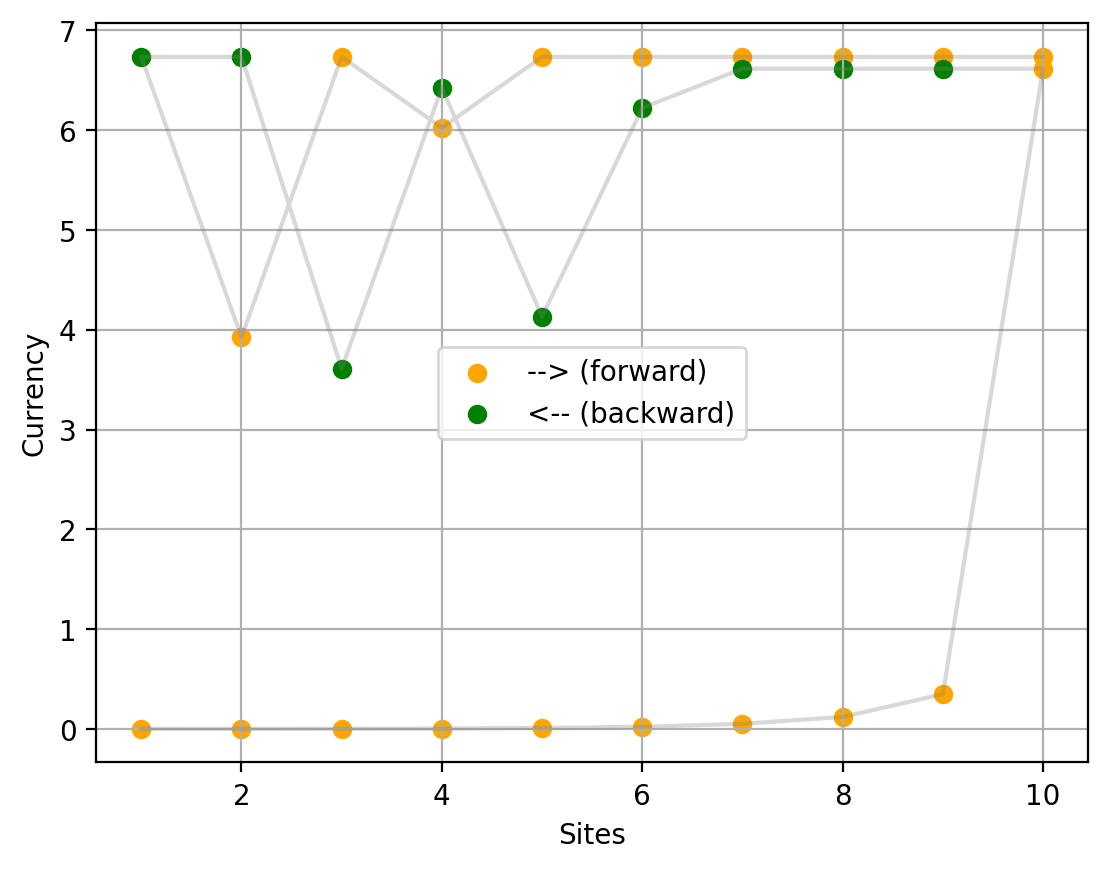

In [15]:
import matplotlib.pyplot as plt

plt.figure(dpi=200)

# Costruisco i punti "forward" (-->)
steps_forward = [s for s, t in zip(steps, types) if t == "-->"]
curr_forward  = [c for c, t in zip(currency, types) if t == "-->"]

# Costruisco i punti "backward" (<--)
steps_backward = [s for s, t in zip(steps, types) if t == "<--"]
curr_backward  = [c for c, t in zip(currency, types) if t == "<--"]

# Scatter separati per avere la legenda
plt.scatter(
    steps_forward,
    curr_forward,
    color="orange",
    label="--> (forward)"
)

plt.scatter(
    steps_backward,
    curr_backward,
    color="green",
    label="<-- (backward)"
)

# Linea di collegamento (facoltativa)
plt.plot(steps, currency, color="gray", alpha=0.3)

# Etichette assi
plt.xlabel("Sites")
plt.ylabel("Currency")

# Griglia
plt.grid(True)

# Legenda
plt.legend()

plt.show()



In [16]:
def build_psi_list(N):
    psi_list = []

    # Sito 1: (1,2)
    A1 = {
        0: np.array([[0.2,  0.3 ]]),
        1: np.array([[ 0.5, 0.2]]),
        2: np.array([[ 0.1, 0.4 ]]),
    }
    psi_list.append(A1)

    # Siti 2..N-1: (2,2)  ← QUI MANCANO NEL TUO FILE
    Ri = {
            0: np.array([[ 0.6,  0.2  ],
                         [     0.8,  0.1  ]]),
            1: np.array([[ 0.3,  0.4  ],
                         [      0.6,  0.2  ]]),
            2: np.array([[ 0,  0.9 ],
                         [    0.4,  0.1  ]]),
        }
    for i in range(2, N):
        psi_list.append(Ri)

    # Sito N: (2,1)
    RN = {
        0: np.array([[ 0.2 ],
                     [ 0.4 ]],),
        1: np.array([[ 0.5 ],
                     [ 0.2 ]]),
        2: np.array([[ 0.7 ],
                     [ 0.1 ]]),
    }
    psi_list.append(RN)
    return psi_list

psi = build_mps(build_psi_list(3),3)
for i in range (psi.L):
    if i == 0 or i == psi.L:
        print(psi.get_B(i).to_ndarray().shape)
        print(psi.get_B(i).to_ndarray().transpose(1,0,2))
    else:
        print(psi.get_B(i).to_ndarray().shape)
        print(psi.get_B(i).to_ndarray().transpose(1,0,2))



(1, 3, 2)
[[[0.2 0.3]]

 [[0.5 0.2]]

 [[0.1 0.4]]]
(2, 3, 2)
[[[0.6 0.2]
  [0.8 0.1]]

 [[0.3 0.4]
  [0.6 0.2]]

 [[0.  0.9]
  [0.4 0.1]]]
(2, 3, 1)
[[[0.2]
  [0.4]]

 [[0.5]
  [0.2]]

 [[0.7]
  [0.1]]]


/opt/homebrew/Caskroom/miniforge/base/envs/moody/lib/python3.11/site-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width)


In [17]:
S0, K, N = 90, 90, 3
d_op, m_op, u_op = 0.9, 1.0, 1.1
pd, pu = 0.25, 0.25   

B_list = build_B_list(S0, K, N, d_op, m_op, u_op, pd, pu)

b = build_mps(B_list, d=3)

for i in range (psi.L):
    if i == 0 or i == psi.L:
        print(b.get_B(i).to_ndarray().shape)
        print(b.get_B(i).to_ndarray().transpose(1,0,2))
    else:
        print(b.get_B(i).to_ndarray().shape)
        print(b.get_B(i).to_ndarray().transpose(1,0,2))

(1, 3, 2)
[[[  6.75 -15.75]]

 [[ 15.   -30.  ]]

 [[  8.25 -14.25]]]
(2, 3, 2)
[[[0.225 0.225]
  [0.    0.25 ]]

 [[0.5   0.5  ]
  [0.    0.5  ]]

 [[0.275 0.275]
  [0.    0.25 ]]]
(2, 3, 1)
[[[0.225]
  [0.25 ]]

 [[0.5  ]
  [0.5  ]]

 [[0.275]
  [0.25 ]]]


In [18]:
def SweepingAlgorithm(b, d, D, err):
    N = b.L
    psi = build_mps(build_psi_list(3),3)
    print("PSI")
    for k in range(psi.L):
        psik = psi.get_B(k).to_ndarray()
        print(f"Site {k}, shape = {psik.shape}:\n{psik.transpose(1,0,2)}\n")


    # overlap iniziale
    k_ref = b.overlap(psi)
    print("First ansatz:",k_ref)

    # primo update sul sito 1 (come prima)
    site = 1
    A_tilde = tensorial_derivative(psi=psi, b=b, site=site)
    A_prime = A_tilde.to_ndarray()
    print("First tensorial derivative",A_prime)
    L_out = newupdate(A_prime)
    d_phys, Dr = L_out.shape
    L = L_out.reshape(1, d_phys, Dr)
    print("First max",L)
    L_tenpy = npc.Array.from_ndarray_trivial(L, labels=['vL', 'p', 'vR'])
    psi.set_B(site - 1, L_tenpy)

    nstep = 1
    updates_since_check = 1   # abbiamo già fatto un update
    K = 3        # o N, 2*N, ecc.
    max_steps = 100000
    #print("PSI")
    #for k in range(psi.L):
    #    psik = psi.get_B(k).to_ndarray()
    #    print(f"Site {k}, shape = {psik.shape}:\n{psik.transpose(1,0,2)}\n")

    while nstep < max_steps:

        # sweep left -> right
        for i in range(N - 1):
            site = i + 1
            if site == 1 and nstep == 1:
                continue
     
            #print("PSI PRE DERIVATA STEP",nstep)
            #for k in range(psi.L):
            #    psik = psi.get_B(k).to_ndarray()
            #    print(f"Site {k}, shape = {psik.shape}:\n{psik.transpose(1,0,2)}\n")
            A_prime = tensorial_derivative(psi=psi, b=b, site=site).to_ndarray()
            #print("-----------")
            print("step:",nstep)
            print("site:",site)
            

            if 1 < site < N:
                Dl, d_phys, Dr = A_prime.shape
                L = newupdate(A_prime.transpose(1,0,2).reshape(Dl * d_phys, Dr)).reshape(d_phys, Dl, Dr).transpose(1,0,2)
                print("tensorial derivative",A_prime.transpose(1,0,2))
                print("maximizer",L.transpose(1,0,2))
            else:
                d_phys, Dr = A_prime.shape
                L =  newupdate(A_prime).reshape(1, d_phys, Dr)
                print("tensorial derivative SPIKE",A_prime)
                print("maximizer",L)

            
            psi.set_B(i, npc.Array.from_ndarray_trivial(L, labels=['vL', 'p', 'vR']))
            #print("PSI")
            #for k in range(psi.L):
            #    psik = psi.get_B(k).to_ndarray()
            #    print(f"Site {k}, shape = {psik.shape}:\n{psik.transpose(1,0,2)}\n")

            nstep += 1
            updates_since_check += 1
            k_curr = b.overlap(psi)
            print("current price",k_curr)
            print("reference price",k_ref)

            if updates_since_check >= K:
                
                if np.abs(k_curr - k_ref) <= err * max(np.abs(k_ref), 1e-12):
                    return psi, k_curr, nstep
                k_ref = k_curr
                updates_since_check = 0
            #print("----------")

        # sweep right -> left
        #print("SWEEP RIGHT")
        for j in range(N - 1, 0, -1):
            site = j + 1
            A_prime = tensorial_derivative(psi=psi, b=b, site=site).to_ndarray()
            #print("-----------")
            print("step:",nstep)
            print("site:",site)

            

            if 1 < site < N:
                Dl, d_phys, Dr = A_prime.shape
                R = newupdate(A_prime.reshape(Dl, Dr * d_phys).T).T.reshape(Dl, d_phys, Dr)
                print("tensorial derivative",A_prime.transpose(1,0,2))
                print("maximizer",R.transpose(1,0,2))
            else:
                Dl, d_phys = A_prime.shape
                R = newupdate(A_prime.T).T.reshape(Dl, d_phys, 1)
                print("tensorial derivative",A_prime)
                print("maximizer",R.transpose(1,0,2))
                print(R.shape)

            psi.set_B(j, npc.Array.from_ndarray_trivial(R, labels=['vL', 'p', 'vR']))

            nstep += 1
            updates_since_check += 1
            k_curr = b.overlap(psi)
            print("current price",k_curr)
            print("reference price",k_ref)
            

            if updates_since_check >= K:
                
                if np.abs(k_curr - k_ref) <= err * max(np.abs(k_ref), 1e-12):
                    return psi, k_curr, nstep
                k_ref = k_curr
                updates_since_check = 0
            #print("----------")

    raise RuntimeError("SweepingAlgorithm did not converge within max_steps")

S0, K, N = 100, 100, 25
d_op, m_op, u_op = 0.9, 1.0, 1.1
pd, pu = 0.25, 0.25   
B_list = build_B_list(S0, K, N, d_op, m_op, u_op, pd, pu)
b = build_mps(B_list, d=3)
psi , K, nstep = SweepingAlgorithm(b=b, d=3, D=2, err=1e-18)
print(nstep)

PSI
Site 0, shape = (1, 3, 2):
[[[0.2 0.3]]

 [[0.5 0.2]]

 [[0.1 0.4]]]

Site 1, shape = (2, 3, 2):
[[[0.6 0.2]
  [0.8 0.1]]

 [[0.3 0.4]
  [0.6 0.2]]

 [[0.  0.9]
  [0.4 0.1]]]

Site 2, shape = (2, 3, 1):
[[[0.2]
  [0.4]]

 [[0.5]
  [0.2]]

 [[0.7]
  [0.1]]]



ValueError: i = 74 out of bounds for finite MPS

In [19]:
psi = build_mps(build_psi_list(3),3)
#for i in range (psi.L):
#    if i == 0 or i == psi.L:
#        print(psi.get_B(i).to_ndarray().shape)
#        print(psi.get_B(i).to_ndarray().transpose(1,0,2))
#    else:
#        print(psi.get_B(i).to_ndarray().shape)
#        print(psi.get_B(i).to_ndarray().transpose(1,0,2))

A = psi.get_B(1).to_ndarray()
print(psi.get_B(1).to_ndarray().transpose(1,0,2))
print(A)
print(A.reshape(2,6))
print(newupdate(A.reshape(2,6).T).T.reshape(2,3,2).transpose(1,0,2))

[[[0.6 0.2]
  [0.8 0.1]]

 [[0.3 0.4]
  [0.6 0.2]]

 [[0.  0.9]
  [0.4 0.1]]]
[[[0.6 0.2]
  [0.3 0.4]
  [0.  0.9]]

 [[0.8 0.1]
  [0.6 0.2]
  [0.4 0.1]]]
[[0.6 0.2 0.3 0.4 0.  0.9]
 [0.8 0.1 0.6 0.2 0.4 0.1]]
[[[0 1]
  [1 0]]

 [[0 1]
  [1 0]]

 [[0 1]
  [1 0]]]


In [20]:

# =========================
# 1) Update rule per A (box [0,1])
# =========================

def update_A_box(deriv: np.ndarray, *, dtype=np.uint8) -> np.ndarray:
    """
    Massimizza <deriv, A> (Frobenius) soggetto a 0 <= A <= 1 (entrywise).
    Soluzione: A_ij = 1 se deriv_ij > 0, altrimenti 0.
    """
    deriv = np.asarray(deriv)
    return (deriv > 0).astype(dtype)


def _to_ndarray(x):
    """Accetta npc.Array oppure ndarray."""
    return x.to_ndarray() if hasattr(x, "to_ndarray") else np.asarray(x)


# =========================
# 2) Update rules coerenti con le vostre (L / R) + A
#    (ritornano sempre shape (Dl, d, Dr) per psi.set_B)
# =========================

def maximize_L_from_derivative(deriv, *, site: int, N: int, dtype=np.uint8) -> np.ndarray:
    """
    Update L come nel vostro SweepingAlgorithm:
    - siti interni: one-hot row-wise su matrice (Dl*d) x Dr
    - bordo sinistro: deriv (d,Dr) -> (1,d,Dr)
    - bordo destro (Dr=1): entrywise threshold (equivalente a one-hot con 1 colonna)
    """
    G = _to_ndarray(deriv)

    if G.ndim == 3:
        Dl, d_phys, Dr = G.shape
        M = G.transpose(1, 0, 2).reshape(Dl * d_phys, Dr)             # (Dl*d) x Dr
        Lm = newupdate(M, dtype=dtype).reshape(d_phys, Dl, Dr).transpose(1, 0, 2)
        return Lm

    if G.ndim == 2:
        if site == 1:
            d_phys, Dr = G.shape
            Lm = newupdate(G, dtype=dtype).reshape(1, d_phys, Dr)
            return Lm
        if site == N:
            Dl, d_phys = G.shape
            # Dr=1: best è 1 dove deriv>0
            return update_A_box(G, dtype=dtype).reshape(Dl, d_phys, 1)

    raise ValueError(f"maximize_L_from_derivative: shape deriv non gestita: {G.shape}, site={site}, N={N}")


def maximize_R_from_derivative(deriv, *, site: int, N: int, dtype=np.uint8) -> np.ndarray:
    """
    Update R come nel vostro SweepingAlgorithm:
    - siti interni: one-hot column-wise via transpose trick
    - bordo destro: deriv (Dl,d) -> (Dl,d,1) con newupdate su (d,Dl)
    - bordo sinistro (Dl=1): entrywise threshold (constraint col-wise è banale)
    """
    G = _to_ndarray(deriv)

    if G.ndim == 3:
        Dl, d_phys, Dr = G.shape
        M = G.reshape(Dl, Dr * d_phys).T                               # (Dr*d) x Dl
        Rm = newupdate(M, dtype=dtype).T.reshape(Dl, d_phys, Dr)
        return Rm

    if G.ndim == 2:
        if site == N:
            Dl, d_phys = G.shape
            # come nel vostro: newupdate su (d, Dl), poi transpose back
            Rm = newupdate(G.T, dtype=dtype).T.reshape(Dl, d_phys, 1)
            return Rm
        if site == 1:
            # Dl=1, deriv tipicamente (d,Dr): entrywise threshold
            d_phys, Dr = G.shape
            return update_A_box(G, dtype=dtype).reshape(1, d_phys, Dr)

    raise ValueError(f"maximize_R_from_derivative: shape deriv non gestita: {G.shape}, site={site}, N={N}")


def maximize_A_from_derivative(deriv, *, site: int, N: int, dtype=np.uint8) -> np.ndarray:
    """
    Update A (box) su tensorial derivative:
    - interno: (Dl,d,Dr)
    - bordo sinistro: deriv (d,Dr) -> (1,d,Dr)
    - bordo destro: deriv (Dl,d) -> (Dl,d,1)
    """
    G = _to_ndarray(deriv)

    if G.ndim == 3:
        return update_A_box(G, dtype=dtype)

    if G.ndim == 2:
        if site == 1:
            d_phys, Dr = G.shape
            return update_A_box(G, dtype=dtype).reshape(1, d_phys, Dr)
        if site == N:
            Dl, d_phys = G.shape
            return update_A_box(G, dtype=dtype).reshape(Dl, d_phys, 1)

    raise ValueError(f"maximize_A_from_derivative: shape deriv non gestita: {G.shape}, site={site}, N={N}")


def apply_update_inplace(psi, b, *, site: int, kind: str, dtype=np.uint8):
    """
    Aggiorna IN PLACE il sito 'site' (1-based) del MPS psi con la update rule corretta.
    kind in {'L','R','A'}.
    """
    N = psi.L
    deriv = tensorial_derivative(psi=psi, b=b, site=site)

    if kind == "L":
        T = maximize_L_from_derivative(deriv, site=site, N=N, dtype=dtype)
    elif kind == "R":
        T = maximize_R_from_derivative(deriv, site=site, N=N, dtype=dtype)
    elif kind == "A":
        T = maximize_A_from_derivative(deriv, site=site, N=N, dtype=dtype)
    else:
        raise ValueError(f"kind sconosciuto: {kind}")

    psi.set_B(site - 1, npc.Array.from_ndarray_trivial(T, labels=["vL", "p", "vR"]))
    return psi


def _cost_scalar(val):
    """Per confronti robusti se overlap ritorna complesso numericamente."""
    v = np.real_if_close(val)
    return float(np.real(v))


def _mps_clone(psi):
    """
    TenPy di solito ha psi.copy(); se non c'è o non è deep, fallback su deepcopy.
    """
    if hasattr(psi, "copy"):
        try:
            return psi.copy()
        except Exception:
            pass
    return copy.deepcopy(psi)


# =========================
# 3) Costruzione iniziale L...A...R (centro in mezzo)
# =========================

def random_A(d: int, Dl: int, Dr: int, seed=None, *, check: bool = True) -> np.ndarray:
    rng = np.random.default_rng(seed)
    A = rng.uniform(0.0, 1.0, size=(d, Dl, Dr)).astype(np.float64)
    if check:
        _check_box_0_1(A)
    return A


def build_mps_LAR(d: int, N: int, D: int, *, center: int = None, seed=None):
    """
    Costruisce MPS iniziale del tipo:
      L_1 ... L_{center-1}  A_center  R_{center+1} ... R_N
    con bond interni costanti = D (bordi: 1).
    """
    if center is None:
        center = (N + 1) // 2
    if not (1 <= center <= N):
        raise ValueError(f"center fuori range: {center} vs N={N}")

    tensors = []
    right_dims = []

    for site in range(1, N + 1):
        Dl = 1 if site == 1 else D
        Dr = 1 if site == N else D

        s = None if seed is None else seed + site

        if site < center:
            T = random_L(d=d, Dl=Dl, Dr=Dr, seed=s)
        elif site == center:
            T = random_A(d=d, Dl=Dl, Dr=Dr, seed=s)
        else:
            T = random_R(d=d, Dl=Dl, Dr=Dr, seed=s)

        tensors.append(T)
        right_dims.append(Dr)

    A_list = [wrap_site_tensor(T) for T in tensors]  # (d,Dl,Dr)-> npc.Array(Dl,d,Dr)
    sites, svs = tenpy_sites_and_svs(d, right_dims)
    return MPS(sites, A_list, svs, bc="finite", form="A"), center


# =========================
# 4) Conflitti (forward e backward)
# =========================

def resolve_forward_conflict(psi, b, *, center: int, dtype=np.uint8):
    """
    Conflitto quando stai andando left->right e arrivi ad A(center).
    Opzioni:
      (1) stay:    A(center)->A'  e  R(center+1)->R'        (se center<N)
      (2) shift:   L(center)->L'  e  A(center+1)->A'        (se center<N)
    Scegli quella con overlap più alto.
    """
    N = psi.L
    if center == N:
        # Non puoi shiftare a destra: fai solo update A
        psi1 = _mps_clone(psi)
        apply_update_inplace(psi1, b, site=center, kind="A", dtype=dtype)
        c1 = _cost_scalar(b.overlap(psi1))
        return psi1, center, {"choice": "stay_edge", "cost_stay": c1, "cost_shift": None}

    # --- stay
    psi_stay = _mps_clone(psi)
    apply_update_inplace(psi_stay, b, site=center,   kind="A", dtype=dtype)
    apply_update_inplace(psi_stay, b, site=center+1, kind="R", dtype=dtype)
    cost_stay = _cost_scalar(b.overlap(psi_stay))

    # --- shift right
    psi_shift = _mps_clone(psi)
    apply_update_inplace(psi_shift, b, site=center,   kind="L", dtype=dtype)
    apply_update_inplace(psi_shift, b, site=center+1, kind="A", dtype=dtype)
    cost_shift = _cost_scalar(b.overlap(psi_shift))

    if cost_stay >= cost_shift:
        return psi_stay, center, {"choice": "stay", "cost_stay": cost_stay, "cost_shift": cost_shift}
    else:
        return psi_shift, center + 1, {"choice": "shift_right", "cost_stay": cost_stay, "cost_shift": cost_shift}


def resolve_backward_conflict(psi, b, *, center: int, dtype=np.uint8):
    """
    Conflitto quando stai andando right->left e arrivi ad A(center).
    Opzioni:
      (1) stay:    A(center)->A'  e  L(center-1)->L'        (se center>1)
      (2) shift:   R(center)->R'  e  A(center-1)->A'        (se center>1)
    Scegli quella con overlap più alto.
    """
    N = psi.L
    if center == 1:
        # Non puoi shiftare a sinistra: fai solo update A
        psi1 = _mps_clone(psi)
        apply_update_inplace(psi1, b, site=center, kind="A", dtype=dtype)
        c1 = _cost_scalar(b.overlap(psi1))
        return psi1, center, {"choice": "stay_edge", "cost_stay": c1, "cost_shift": None}

    # --- stay
    psi_stay = _mps_clone(psi)
    apply_update_inplace(psi_stay, b, site=center,   kind="A", dtype=dtype)
    apply_update_inplace(psi_stay, b, site=center-1, kind="L", dtype=dtype)
    cost_stay = _cost_scalar(b.overlap(psi_stay))

    # --- shift left
    psi_shift = _mps_clone(psi)
    apply_update_inplace(psi_shift, b, site=center,   kind="R", dtype=dtype)
    apply_update_inplace(psi_shift, b, site=center-1, kind="A", dtype=dtype)
    cost_shift = _cost_scalar(b.overlap(psi_shift))

    if cost_stay >= cost_shift:
        return psi_stay, center, {"choice": "stay", "cost_stay": cost_stay, "cost_shift": cost_shift}
    else:
        return psi_shift, center - 1, {"choice": "shift_left", "cost_stay": cost_stay, "cost_shift": cost_shift}


# =========================
# 5) Algoritmo completo: sweeping + conflitti
# =========================

def ConflictSweepingAlgorithm(
    b,
    *,
    d: int,
    D: int,
    err: float,
    center: int = None,
    seed=None,
    max_cycles: int = 200,
    dtype=np.uint8,
    verbose: bool = False,
):
    """
    Sweeping migliorato con conflitti.
    Monotonia: ogni update locale (L/R/A) è un massimizzatore del Frobenius product
    sul feasible set del sito; ai conflitti scegliamo la migliore tra due mosse.

    Stop: dopo ogni ciclo completo (forward+backward) se miglioramento relativo <= err.
    """
    N = b.L
    psi, center = build_mps_LAR(d=d, N=N, D=D, center=center, seed=seed)

    history = []
    cost = _cost_scalar(b.overlap(psi))
    history.append({"event": "init", "center": center, "cost": cost})

    for cyc in range(max_cycles):
        cost_start = cost

        # =========
        # FORWARD: aggiorna L fino a center-1
        # =========
        for site in range(1, center):
            apply_update_inplace(psi, b, site=site, kind="L", dtype=dtype)
            if verbose:
                cnow = _cost_scalar(b.overlap(psi))
                history.append({"event": "L_update", "site": site, "center": center, "cost": cnow})

        old_center = center

        # conflitto forward (A vs spostamento a destra)
        psi, center, info = resolve_forward_conflict(psi, b, center=old_center, dtype=dtype)
        if verbose:
            cnow = _cost_scalar(b.overlap(psi))
            history.append({"event": "forward_conflict", "old_center": old_center, "new_center": center,
                            "choice": info["choice"], "cost": cnow, **info})

        # aggiorna R dal sito old_center+2 fino a N
        for site in range(old_center + 2, N + 1):
            apply_update_inplace(psi, b, site=site, kind="R", dtype=dtype)
            if verbose:
                cnow = _cost_scalar(b.overlap(psi))
                history.append({"event": "R_update_forward", "site": site, "center": center, "cost": cnow})

        # =========
        # BACKWARD: aggiorna R da N fino a center+1
        # =========
        for site in range(N, center, -1):
            apply_update_inplace(psi, b, site=site, kind="R", dtype=dtype)
            if verbose:
                cnow = _cost_scalar(b.overlap(psi))
                history.append({"event": "R_update_backward", "site": site, "center": center, "cost": cnow})

        old_center = center

        # conflitto backward (A vs spostamento a sinistra)
        psi, center, info = resolve_backward_conflict(psi, b, center=old_center, dtype=dtype)
        if verbose:
            cnow = _cost_scalar(b.overlap(psi))
            history.append({"event": "backward_conflict", "old_center": old_center, "new_center": center,
                            "choice": info["choice"], "cost": cnow, **info})

        # aggiorna L dal sito old_center-2 fino a 1
        for site in range(old_center - 2, 0, -1):
            apply_update_inplace(psi, b, site=site, kind="L", dtype=dtype)
            if verbose:
                cnow = _cost_scalar(b.overlap(psi))
                history.append({"event": "L_update_backward", "site": site, "center": center, "cost": cnow})

        # =========
        # Check stop (fine ciclo)
        # =========
        cost = _cost_scalar(b.overlap(psi))
        history.append({"event": "cycle_end", "cycle": cyc, "center": center, "cost": cost})

        denom = max(abs(cost_start), 1e-12)
        if abs(cost - cost_start) <= err * denom:
            history.append({"event": "stop", "cycle": cyc, "center": center, "cost": cost,
                            "reason": "relative_improvement_below_err"})
            break

    return psi, cost, center, history

In [ ]:
S0, K, N = 7, 600, 10
d_op, m_op, u_op = 0.9, 1.0, 1.5
pd, pu = 0.35, 0.35   
B_list = build_B_list(S0, K, N, d_op, m_op, u_op, pd, pu)
b = build_mps(B_list, d=3)


psi_opt, best_cost, center_finale, hist = ConflictSweepingAlgorithm(
    b,
    d=3,
    D=10,
    err=1e-6,
    verbose=False,   # True se vuoi log ad ogni update
    max_cycles=200,
    seed=123
)

print("best_cost =", best_cost, "center_finale =", center_finale)

best_cost = 2706.67746224482 center_finale = 5
